## Imports 

In [78]:
import MDAnalysis as mda
import numpy as np
import pandas as pd
from MDAnalysis.analysis import distances
from pathlib import Path
import matplotlib.pyplot as plt
import re

## Processing files

In [79]:
data_dir = Path('./')
out_dir  = data_dir / 'contacts_dat'
out_dir.mkdir(exist_ok=True)

pdb_files = sorted(data_dir.glob('*.pdb'))
pairs = []
for pdb in pdb_files:
    dcd = pdb.with_suffix('.dcd')
    if dcd.exists():
        pairs.append((pdb, dcd))
    else:
        print(f'⚠️  no DCD for {pdb.name}, skipping')

print(f'→ will process {len(pairs)} trajectories')

⚠️  no DCD for rebuilt_structure.pdb, skipping
→ will process 6 trajectories


## Loop through each trajectory, compute distances, save .dat

In [80]:
cutoff = 4.0  # Å
for pdb, dcd in pairs:
    u = mda.Universe(pdb, dcd)
    donors    = u.select_atoms('name HBG')
    acceptors = u.select_atoms('name HBP')
    records = []

    for ts in u.trajectory:
        frame = ts.frame
        D = distances.distance_array(donors.positions,
                                     acceptors.positions,
                                     box=u.dimensions)
        found = False

        # collect all inter‐chain contacts ≤ cutoff
        for i in range(D.shape[0]):
            for j in range(D.shape[1]):
                if (donors[i].segid != acceptors[j].segid) and (D[i,j] <= cutoff):
                    records.append((frame,
                                    donors.indices[i],
                                    acceptors.indices[j],
                                    D[i,j]))
                    found = True

        # if none, add a dummy zero‐contact row
        if not found:
            records.append((frame, 0, 0, 0.0))

    df = pd.DataFrame(records,
                      columns=['Frame','HBG_index','HBP_index','Distance (Å)'])
    out_file = out_dir / f'{pdb.stem}_contacts.dat'
    df.to_csv(out_file, sep='\t', index=False)
    print(f'wrote {out_file.name} ({len(df)} rows)')

/mnt/home/rsantos/openmm-env/lib/python3.11/site-packages/MDAnalysis/coordinates/DCD.py:165: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


wrote cgtriple050K_contacts.dat (139895 rows)
wrote cgtriple100K_contacts.dat (147803 rows)
wrote cgtriple150K_contacts.dat (142825 rows)
wrote cgtriple200K_contacts.dat (136983 rows)
wrote cgtriple250K_contacts.dat (114906 rows)
wrote cgtriple300K_contacts.dat (87344 rows)


## Counting the contacts

In [81]:
contacts_dir = out_dir  
for contact_file in contacts_dir.glob('*_contacts.dat'):
    df = pd.read_csv(contact_file, sep='\t')

    all_frames = sorted(df['Frame'].unique())
    real = df[df['HBG_index'] != 0]             # drop dummy rows
    counts = real.groupby('Frame').size()       # count real contacts
    counts = counts.reindex(all_frames, fill_value=0)

    count_per_frame = counts.reset_index(name='NumContacts')
    out_count = contact_file.with_name(f"{contact_file.stem}_count.dat")
    count_per_frame.to_csv(out_count, sep='\t', index=False)
    print(f'wrote {out_count.name}')

wrote cgtriple150K_contacts_count.dat
wrote cgtriple300K_contacts_count.dat
wrote cgtriple200K_contacts_count.dat
wrote cgtriple250K_contacts_count.dat
wrote cgtriple050K_contacts_count.dat
wrote cgtriple100K_contacts_count.dat


## Plotting 

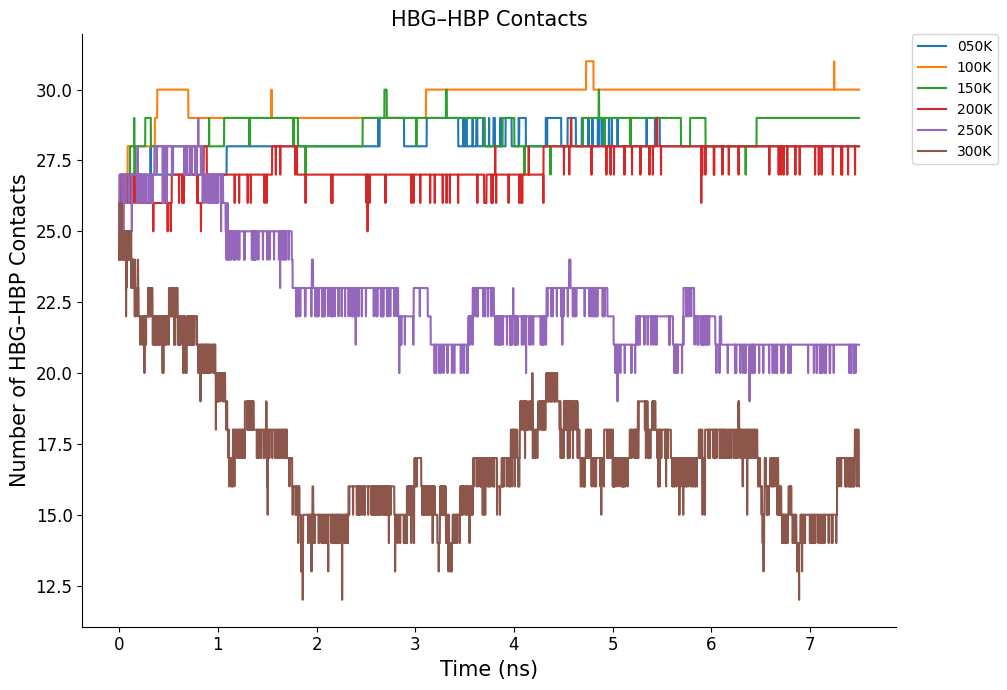

In [83]:
contacts_count_dir = Path('./contacts_dat')

# time‐step conversion (same as before)
dt_ps = 1.5           # ps per frame
dt_ns = dt_ps * 1e-3    # ns per frame

fig, ax = plt.subplots(figsize=(12,7))

for count_file in sorted(contacts_count_dir.glob('*_count.dat')):
    df = pd.read_csv(count_file, sep='\t')
    # convert Frame → Time (ns)
    df['Time (ns)'] = df['Frame'] * dt_ns
    
    # extract just the temperature label
    m = re.search(r'(\d+K)', count_file.stem)
    label = m.group(1) if m else count_file.stem

    ax.plot(df['Time (ns)'],
             df['NumContacts'],
             label=label)

# remove only the top and right plot borders (spines)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
    
ax.set_xlabel('Time (ns)', fontsize=15)
ax.set_ylabel('Number of HBG–HBP Contacts', fontsize=15)
ax.set_title('HBG–HBP Contacts', fontsize=15)
ax.tick_params(axis='both', labelsize=12)

# move legend outside to the right
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0, fontsize=10)

# adjust layout to make room for the legend
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

## Faceted Small Multiples 

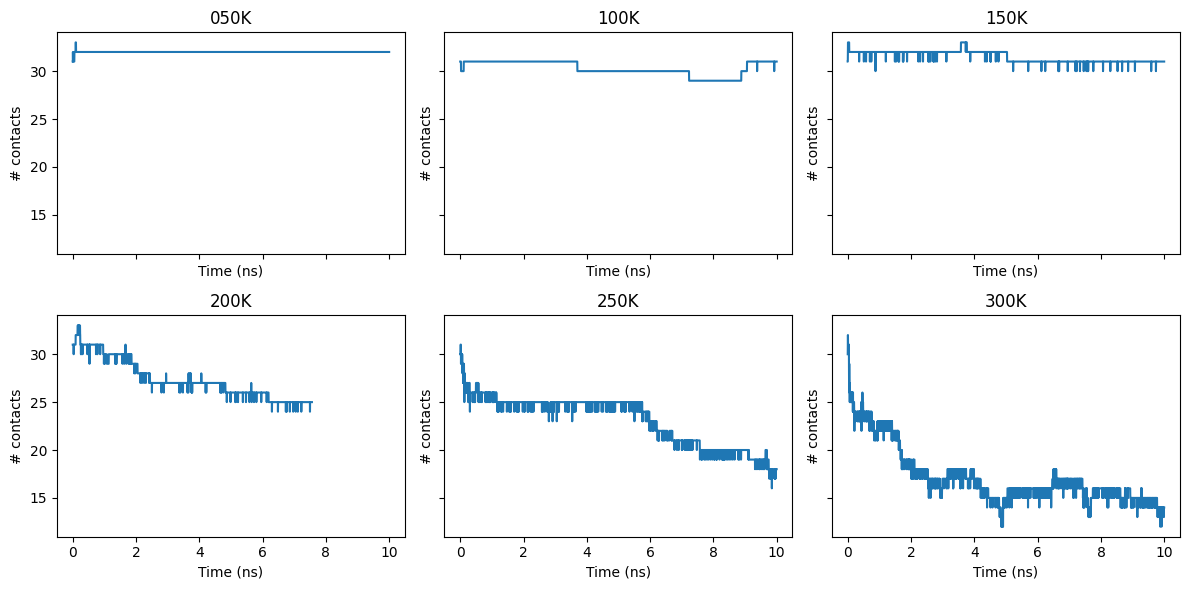

In [47]:
contacts_count_dir = Path('contacts_dat')
files = sorted(contacts_count_dir.glob('*_count.dat'))
n = len(files)
cols = 3
rows = (n + cols - 1)//cols

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows), sharex=True, sharey=True)
axes = axes.flatten()

dt_ps = 2; dt_ns = dt_ps * 1e-3

for ax, f in zip(axes, files):
    df = pd.read_csv(f, sep='\t')
    df['Time (ns)'] = df['Frame'] * dt_ns
    ax.plot(df['Time (ns)'], df['NumContacts'])
    
    # extract filename
    m = re.search(r'(\d+K)', f.stem)
    title = m.group(1) if m else f.stem
    
    ax.set_title(title)
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel('# contacts')

# turn off unused subplots
for ax in axes[n:]:
    ax.axis('off')

plt.tight_layout()
